<a href="https://colab.research.google.com/github/sindhuudivyapriya1998-collab/Brain-Tumour-MRI-image-classification/blob/main/BrainMRI_project5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Brain Tumor MRI Image Classification


In [3]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
test_data ="/content/drive/MyDrive/Tumour/test"
train_data ="/content/drive/MyDrive/Tumour/train"
valid_data ="/content/drive/MyDrive/Tumour/valid"

#Data Preprocessing

In [6]:
train_datagen = ImageDataGenerator()
valid_datagen = ImageDataGenerator(rescale= 1. /255)
test_datagen = ImageDataGenerator(rescale= 1. /255)

train_generator = train_datagen.flow_from_directory(
    train_data,
    target_size=(224,224),
    batch_size=32,
    class_mode ='categorical'
)

print(train_generator.class_indices)

Found 1695 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [8]:
images, labels = next(train_generator)

print("image shape:", images.shape)
print("Label shape:", labels.shape)

image shape: (32, 224, 224, 3)
Label shape: (32, 4)


In [7]:
img_width, img_height = 224, 224  # Adjust as needed
batch_size = 32  # Adjust as needed

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_data,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'  # or 'binary' if you have two classes
)

validation_generator = valid_datagen.flow_from_directory(
    valid_data,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_data,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Important for evaluating the test set
)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


#Data Augmentation

In [9]:
train_datagen = ImageDataGenerator(rescale=1. /255,
                          rotation_range=20,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   zoom_range=0.2,
                                   horizontal_flip=True)



In [10]:
train_generator = train_datagen.flow_from_directory(
    train_data,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'# or 'binary' if you have two classes
)

Found 1695 images belonging to 4 classes.


In [11]:
class_names = list(validation_generator.class_indices.keys())
num_classes = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

Class names: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


#CNN Model Building

In [12]:
model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
                loss ='categorical_crossentropy',
                metrics=['accuracy',
                  tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])

# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_282 (Conv2D)             │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_282         │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_283 (Conv2D)             │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_283         │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_284 (Conv2D)             │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_284         │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_transfer_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [14]:
epochs = 5
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[early_stop,checkpoint]
)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 789ms/step - accuracy: 0.6472 - loss: 0.9059 - precision: 0.7561 - recall: 0.5086 - val_accuracy: 0.3665 - val_loss: 1.3084 - val_precision: 0.8333 - val_recall: 0.0199
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 612ms/step - accuracy: 0.7015 - loss: 0.7749 - precision: 0.7698 - recall: 0.5900 - val_accuracy: 0.3347 - val_loss: 1.4952 - val_precision: 0.6964 - val_recall: 0.3108
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 615ms/step - accuracy: 0.7221 - loss: 0.7159 - precision: 0.7908 - recall: 0.6289 - val_accuracy: 0.3386 - val_loss: 1.9135 - val_precision: 0.3797 - val_recall: 0.3207
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 576ms/step - accuracy: 0.7345 - loss: 0.6755 - precision: 0.7918 - recall: 0.6643 - val_accuracy: 0.4622 - val_loss: 1.8377 - val_precision: 0.4703 - val_recall: 0.3944
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 30s 567ms/step - accuracy: 0.7617 - loss: 0.6158 - precision: 0.8113 - recall: 0.6950 - val_accuracy: 0.5498 - val_loss: 1.

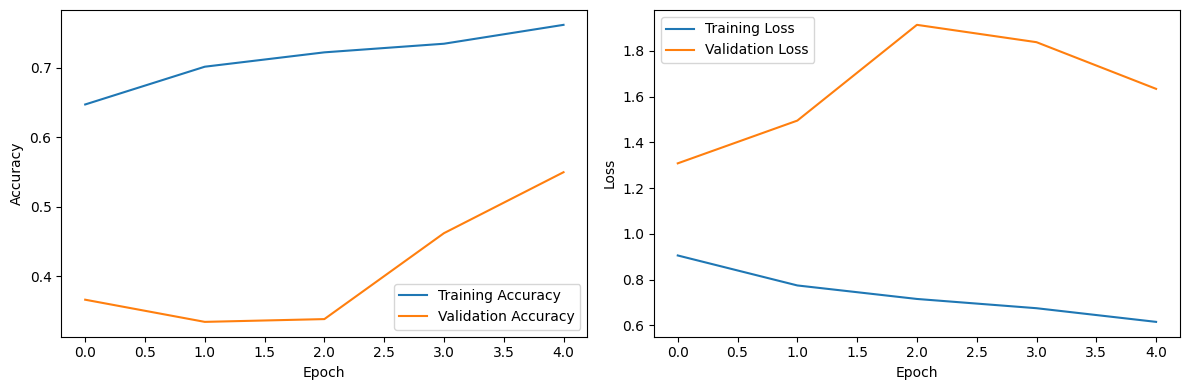

In [15]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [16]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

In [17]:
test_loss, test_acc, test_precision, test_recall = model.evaluate(test_generator)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f'Test precision: {test_precision:.4f}')
print(f'Test recall: {test_recall:.4f}')

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.4024 - loss: 1.3055 - precision: 0.7500 - recall: 0.0122

Test accuracy: 0.4024
Test precision: 0.7500
Test recall: 0.0122


In [18]:
print("current model test:")
model.evaluate(test_generator)

current model test:
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.4024 - loss: 1.3055 - precision: 0.7500 - recall: 0.0122


[1.3055479526519775, 0.40243902802467346, 0.75, 0.012195121496915817]

#Transfer Learning

#MobileNetV2

In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights ='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation ='relu')(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

MobileNetV2_model = Model(base_model.input, output)

MobileNetV2_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy',tf.keras.metrics.Precision(name='precision'),
                         tf.keras.metrics.Recall(name='recall')]
    )

mobilenetv2_transfer = MobileNetV2_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6295 - loss: 0.9331 - precision: 0.6900 - recall: 0.5593 - val_accuracy: 0.7689 - val_loss: 0.5945 - val_precision: 0.8027 - val_recall: 0.7211
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 554ms/step - accuracy: 0.7729 - loss: 0.5729 - precision: 0.8185 - recall: 0.7345 - val_accuracy: 0.7749 - val_loss: 0.5292 - val_precision: 0.8162 - val_recall: 0.7430
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 554ms/step - accuracy: 0.8047 - loss: 0.5069 - precision: 0.8368 - recall: 0.7622 - val_accuracy: 0.7948 - val_loss: 0.5165 - val_precision: 0.8254 - val_recall: 0.7629
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 30s 563ms/step - accuracy: 0.8201 - loss: 0.4599 - precision: 0.8451 - recall: 0.7917 - val_accuracy: 0.7709 - val_loss: 0.5572 - val_precision: 0.8004 - val_recall: 0.7510
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 30s 562ms/step - accuracy: 0.8330 - loss: 0.4415 - precision: 0.8504 - recall: 0.8083 - val_accuracy: 0.8187 - val_loss: 

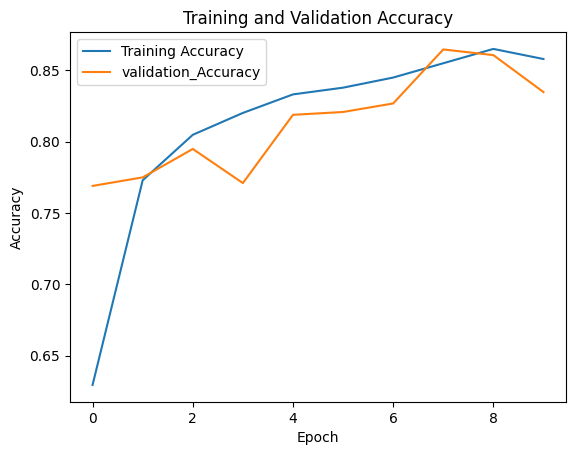

In [20]:
import matplotlib.pyplot as plt

plt.plot(mobilenetv2_transfer.history['accuracy'], label ='Training Accuracy')
plt.plot(mobilenetv2_transfer.history['val_accuracy'], label='validation_Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

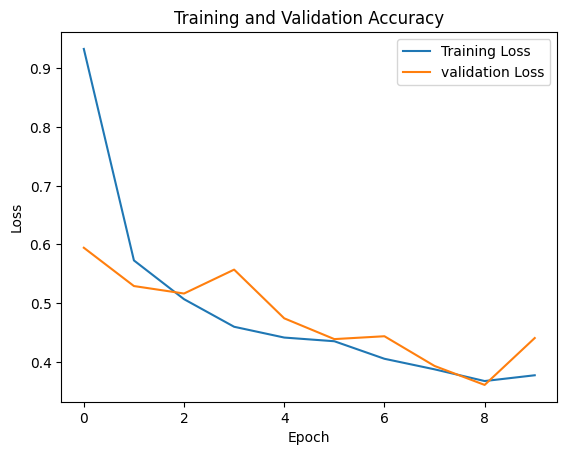

In [21]:
plt.plot(mobilenetv2_transfer.history['loss'], label='Training Loss')
plt.plot(mobilenetv2_transfer.history['val_loss'], label='validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.7846 - loss: 0.5434 - precision: 0.7958 - recall: 0.7764

MobileNet Test accuracy: 0.7846
MobileNet Test precision: 0.7958
MobileNet Test recall: 0.7764
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 895ms/step


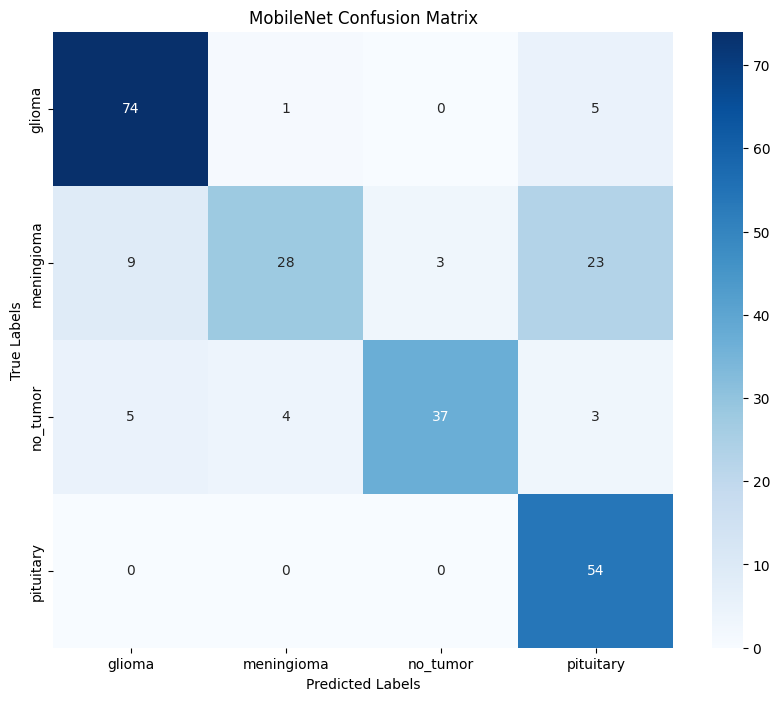

In [22]:
import seaborn as sns

test_generator.reset()  # Reset the generator before evaluating
test_loss, test_acc, test_precision, test_recall = MobileNetV2_model.evaluate(test_generator)
print(f'\nMobileNet Test accuracy: {test_acc:.4f}')
print(f'MobileNet Test precision: {test_precision:.4f}')
print(f'MobileNet Test recall: {test_recall:.4f}')

# Generate predictions for MobileNet
predictions = MobileNetV2_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Get true classes for MobileNet
true_classes = test_generator.classes

# Confusion Matrix for MobileNet
conf_mat = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix for MobileNet using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('MobileNet Confusion Matrix')
plt.show()

#InceptionV3

In [23]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf


base_model = InceptionV3(
    weights ='imagenet',
    include_top=False,
    input_shape=(299,299,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation ='relu')(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

InceptionV3_model = Model(base_model.input, output)

InceptionV3_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy',tf.keras.metrics.Precision(name='precision'),
                         tf.keras.metrics.Recall(name='recall')]
)
train_generator = train_datagen.flow_from_directory(
    train_data,
    target_size=(299,299),
    batch_size=32,
    class_mode ='categorical'
)

validation_generator=valid_datagen.flow_from_directory(
    train_data,
    target_size=(299,299),
    batch_size=32,
    class_mode ='categorical'
)


InceptionV3_transfer = InceptionV3_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

Found 1695 images belonging to 4 classes.
Found 1695 images belonging to 4 classes.
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.6136 - loss: 0.9738 - precision: 0.7075 - recall: 0.4909 - val_accuracy: 0.7463 - val_loss: 0.6035 - val_precision: 0.7890 - val_recall: 0.7168
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.7587 - loss: 0.6197 - precision: 0.8145 - recall: 0.7074 - val_accuracy: 0.8584 - val_loss: 0.3969 - val_precision: 0.8861 - val_recall: 0.8265
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.7864 - loss: 0.5366 - precision: 0.8220 - recall: 0.7440 - val_accuracy: 0.8637 - val_loss: 0.4057 - val_precision: 0.8900 - val_recall: 0.8260
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8159 - loss: 0.4810 - precision: 0.8545 - recall: 0.7729 - val_accuracy: 0.8838 - val_loss: 0.3201 - val_precision: 0.9041 - val_recall: 0.8625
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8189 - loss: 0.4832

8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7724 - loss: 0.6238 - precision: 0.7759 - recall: 0.7602

Inceptionv3 Test accuracy: 0.7724
Inceptionv3 Test precision: 0.7759
Inceptionv3 Test recall: 0.7602
Found 246 images belonging to 4 classes.
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step


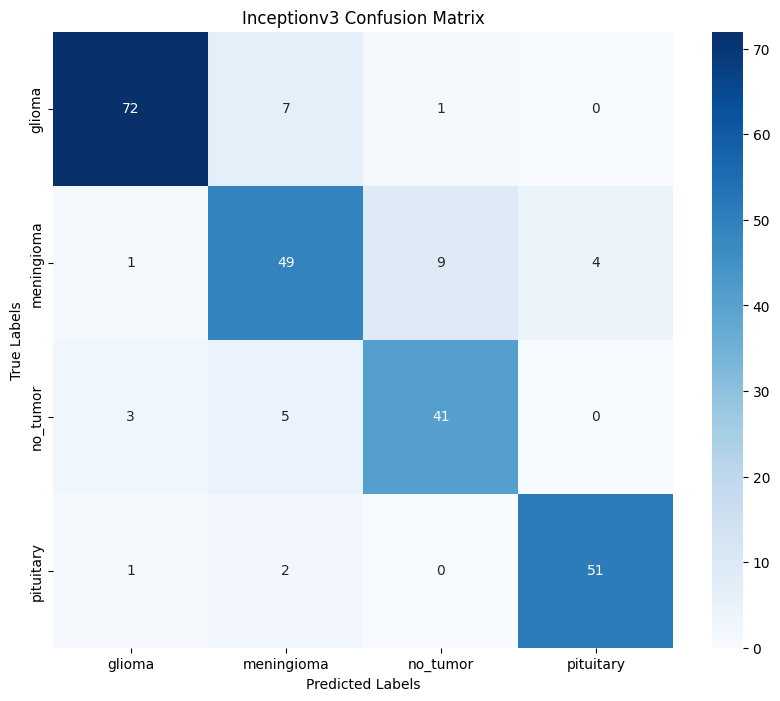

In [24]:
import seaborn as sns

test_generator.reset()  # Reset the generator before evaluating
test_loss, test_acc, test_precision, test_recall = InceptionV3_model.evaluate(test_generator)
print(f'\nInceptionv3 Test accuracy: {test_acc:.4f}')
print(f'Inceptionv3 Test precision: {test_precision:.4f}')
print(f'Inceptionv3 Test recall: {test_recall:.4f}')

test_generator = test_datagen.flow_from_directory(
    test_data,
    target_size=(299, 299),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Important for evaluating the test set
)

# Generate predictions for inceptionv3
predictions = InceptionV3_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Get true classes for inceptionv3
true_classes = test_generator.classes

# Confusion Matrix for inceptionv3
conf_mat = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix for inceptionv3 using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Inceptionv3 Confusion Matrix')
plt.show()

#ResNet50

In [25]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights ='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
train_generator = train_datagen.flow_from_directory(
    train_data,
    target_size=(224,224),
    batch_size=32,
    class_mode ='categorical'
)
validation_generator = valid_datagen.flow_from_directory(
    valid_data,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation ='relu')(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

ResNet50_model = Model(base_model.input, output)

ResNet50_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy',tf.keras.metrics.Precision(name='precision'),
                         tf.keras.metrics.Recall(name='recall')]
)

resnet50_transfer = ResNet50_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=5,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 59s 851ms/step - accuracy: 0.3091 - loss: 1.5736 - precision: 0.3207 - recall: 0.1251 - val_accuracy: 0.4661 - val_loss: 1.2842 - val_precision: 0.7500 - val_recall: 0.0179
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 30s 569ms/step - accuracy: 0.3693 - loss: 1.3262 - precision: 0.5226 - recall: 0.0749 - val_accuracy: 0.4502 - val_loss: 1.2340 - val_precision: 0.8000 - val_recall: 0.0478
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 589ms/step - accuracy: 0.3929 - loss: 1.2836 - precision: 0.5630 - recall: 0.1186 - val_accuracy: 0.5378 - val_loss: 1.1665 - val_precision: 0.8571 - val_recall: 0.0956
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 30s 569ms/step - accuracy: 0.4360 - loss: 1.2522 - precision: 0.5925 - recall: 0.1398 - val_accuracy: 0.5777 - val_loss: 1.1464 - val_precision: 0.8727 - val_recall: 0.0956
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 30s 568ms/step - accuracy: 0.4442 - loss

#Model comparison

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

test_generator_299 = test_datagen.flow_from_directory(
    test_data,
    target_size=(299, 299),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Important for evaluating the test set
)
test_generator_224 = test_datagen.flow_from_directory(
    test_data,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Important for evaluating the test set
)

models ={
    "Custom CNN":(model, test_generator_224),
    "MobileNetv2":(MobileNetV2_model,test_generator_224),
    "Inceptionv3":(InceptionV3_model,test_generator_299),
    "ResNet50":(ResNet50_model,test_generator_224)
}

results = []

for model_name, (current_model, current_generator) in models.items():
    current_generator.reset()

    y_prob = current_model.predict(current_generator)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_generator.classes

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted',zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted',zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted',zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Val Accuracy": accuracy * 100,
        "Val Precision": precision * 100,
        "Val Recall": recall * 100,
        "F1 score": f1 * 100,
        "Parameters":model.count_params()
    })
comparison_df = pd.DataFrame(results)

comparison = comparison_df.sort_values("Val Accuracy", ascending=False)

comparison = comparison.round(2)
print(comparison)

Found 246 images belonging to 4 classes.
Found 246 images belonging to 4 classes.
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step
         Model  Accuracy  Precision  Recall  Val Accuracy  Val Precision  \
2  Inceptionv3      0.87       0.87    0.87         86.59          86.70   
1  MobileNetv2      0.78       0.81    0.78         78.46          81.45   
3     ResNet50      0.53       0.42    0.53         53.25          41.83   
0   Custom CNN      0.40       0.34    0.40         40.24          33.77   

   Val Recall  F1 score  Parameters  
2       86.59     86.62      111172  
1       78.46     77.21      111172  
3       53.25     45.95      111172  
0       40.24     29.63      111172  


#Results Comparison

In [28]:
comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
comparison_df.style.background_gradient(cmap='Blues', subset=['Val Accuracy', 'Val Precision', 'Val Recall'])

,Model,Accuracy,Precision,Recall,Val Accuracy,Val Precision,Val Recall,F1 score,Parameters
2,Inceptionv3,0.870000,0.870000,0.870000,86.590000,86.700000,86.590000,86.620000,111172
1,MobileNetv2,0.780000,0.810000,0.780000,78.460000,81.450000,78.460000,77.210000,111172
3,ResNet50,0.530000,0.420000,0.530000,53.250000,41.830000,53.250000,45.950000,111172
0,Custom CNN,0.400000,0.340000,0.400000,40.240000,33.770000,40.240000,29.630000,111172


In [29]:
comparison_df.to_csv('/content/drive/MyDrive/model_comparison.csv', index=False)

In [30]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/model_comparison.csv')
df

,Model,Accuracy,Precision,Recall,Val Accuracy,Val Precision,Val Recall,F1 score,Parameters
0,Inceptionv3,0.87,0.87,0.87,86.59,86.70,86.59,86.62,111172
1,MobileNetv2,0.78,0.81,0.78,78.46,81.45,78.46,77.21,111172
2,ResNet50,0.53,0.42,0.53,53.25,41.83,53.25,45.95,111172
3,Custom CNN,0.40,0.34,0.40,40.24,33.77,40.24,29.63,111172


The best performing model is:
Model            Inceptionv3
Accuracy                0.87
Precision               0.87
Recall                  0.87
Val Accuracy           86.59
Val Precision           86.7
Val Recall             86.59
F1 score               86.62
Parameters            111172
Name: 0, dtype: object


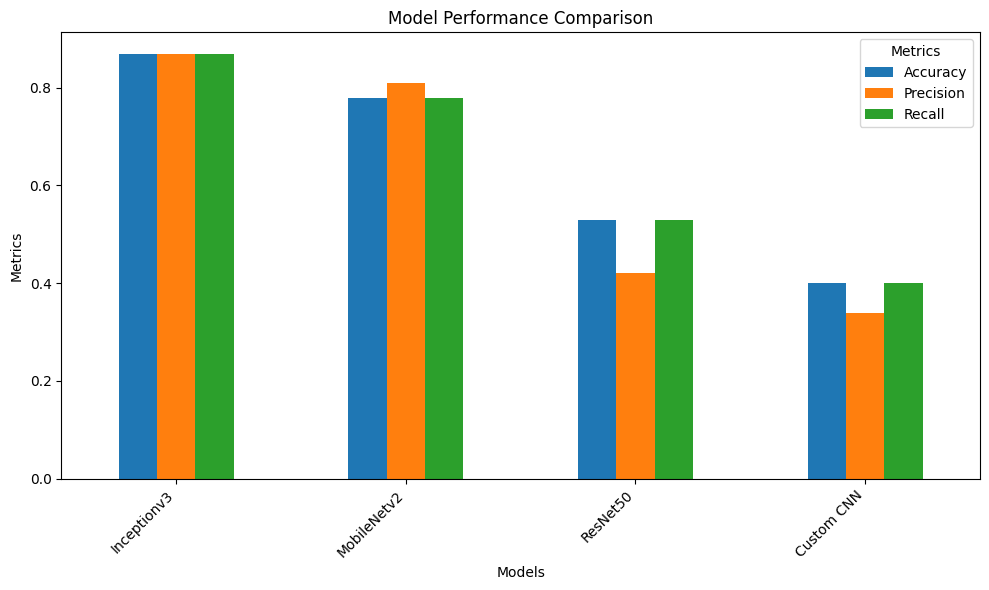

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/model_comparison.csv')


# Find the best model based on validation accuracy
best_model = df.loc[df['Accuracy'].idxmax()]

print(f"The best performing model is:\n{best_model}")

# Plotting the bar chart
plt.figure(figsize=(10, 6))
df.plot(x='Model', y=['Accuracy', 'Precision', 'Recall'], kind='bar', ax=plt.gca())
plt.title('Model Performance Comparison')
plt.ylabel('Metrics')
plt.xlabel('Models')


plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

#Save the model

In [32]:
InceptionV3_model.save('/content/drive/MyDrive/InceptionV3_brain_tumour.h5')

In [33]:
import os
os.path.exists('/content/drive/MyDrive/InceptionV3_brain_tumour.h5')

True

#Streamlit

In [34]:
!pip install streamlit numpy pillow tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 107.1 MB/s eta 0:00:00


In [35]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-08-22 06:45:07--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.8.2/cloudflared-linux-amd64 [following]
--2026-08-22 06:45:08--  https://github.com/cloudflare/cloudflared/releases/download/2026.8.2/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/e3f3cf2d-059b-45ec-a36b-ef2d5be35667?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-22T07%3A34%3A48Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-08-22T0

In [36]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [37]:
%%writefile Brain_MRI.py

import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model
import os

classes =['glioma','meningioma','no tumour','pituitary']

# Load stom trained model
@st.cache_resource
def load_custom_model():
    model_path = '/content/drive/MyDrive/InceptionV3_brain_tumour.h5'
    if not os.path.exists(model_path):
        st.error(f"Model file not found at {model_path}")
        return None
    return load_model(model_path)

model = load_custom_model()

uploaded_file = st.file_uploader("Choose a MRI image...",
                                type=["jpg", "jpeg", "png"])

if uploaded_file is not None and model is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded MRI', use_container_width=True)

    # Preprocess the image
    image = image.resize((299, 299))  # Match your model's expected input
    image_array = img_to_array(image)
    image_array = image_array / 255.0  # Normalize (if your model expects this)
    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array)
    class_index = np.argmax(prediction)


    st.success(f"Prediction:{classes[class_index]}")


Writing Brain_MRI.py


In [38]:
!streamlit run /content/Brain_MRI.py &>/content/logs.txt &

In [39]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://signing-adjustments-threats-demonstrate.trycloudflare.com
